In [1]:
!pip install pandas numpy scikit-learn imbalanced-learn seaborn matplotlib


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE


In [3]:
df = pd.read_csv("creditcard.csv")
print("✅ Data loaded successfully!")
print(df.head())


✅ Data loaded successfully!
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

In [4]:
print("\nChecking for missing values:")
print(df.isnull().sum())



Checking for missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [5]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

print("✅ Normalization done!")
print(df[['Amount', 'Time']].head())


✅ Normalization done!
     Amount      Time
0  0.244964 -1.996583
1 -0.342475 -1.996583
2  1.160686 -1.996562
3  0.140534 -1.996562
4 -0.073403 -1.996541


In [6]:
X = df.drop('Class', axis=1)
y = df['Class']
print("✅ Features and target separated.")


✅ Features and target separated.


In [7]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("✅ After SMOTE balancing:")
print(y_resampled.value_counts())


✅ After SMOTE balancing:
Class
0    284315
1    284315
Name: count, dtype: int64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=42
)

print("✅ Train/Test Split Done.")
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


✅ Train/Test Split Done.
Training samples: (398041, 30)
Testing samples: (170589, 30)


In [9]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("✅ Logistic Regression model trained.")


✅ Logistic Regression model trained.


In [23]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("✅ Random Forest model trained.")



✅ Random Forest model trained.
Fitting started...
Fitting done.


In [25]:
def evaluate_model(y_test, y_pred, y_prob, model_name):
    print(f"\n===== {model_name} Evaluation =====")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    roc = roc_auc_score(y_test, y_prob)
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    
    print(f"ROC-AUC: {roc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    return roc, pr_auc


In [26]:
roc_lr, pr_lr = evaluate_model(y_test, y_pred_lr, y_prob_lr, "Logistic Regression")
roc_rf, pr_rf = evaluate_model(y_test, y_pred_rf, y_prob_rf, "Random Forest")



===== Logistic Regression Evaluation =====
Confusion Matrix:
 [[83058  2091]
 [ 6687 78753]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95     85149
           1       0.97      0.92      0.95     85440

    accuracy                           0.95    170589
   macro avg       0.95      0.95      0.95    170589
weighted avg       0.95      0.95      0.95    170589

ROC-AUC: 0.9895
PR-AUC: 0.9909

===== Random Forest Evaluation =====
Confusion Matrix:
 [[85133    16]
 [    0 85440]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85149
           1       1.00      1.00      1.00     85440

    accuracy                           1.00    170589
   macro avg       1.00      1.00      1.00    170589
weighted avg       1.00      1.00      1.00    170589

ROC-AUC: 1.0000
PR-AUC: 1.0000


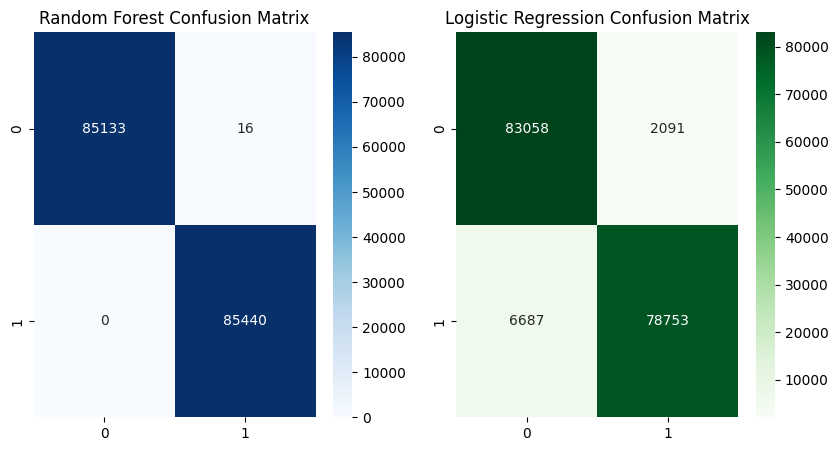

In [27]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')

plt.subplot(1,2,2)
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Greens')
plt.title('Logistic Regression Confusion Matrix')

plt.show()


In [28]:
# Suppose a new transaction (scaled values)
sample = X_test.iloc[0].values.reshape(1, -1)
prediction = rf.predict(sample)[0]

if prediction == 1:
    print("🚨 Fraudulent Transaction Detected!")
else:
    print("✅ Normal Transaction.")


🚨 Fraudulent Transaction Detected!


C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
